---

# Homework 3

**Course:** CSCE-636-700

**Instructor:** Dr. Anxiao Jiang

**Author:** Brody Jordan (431005357)

---

 ## Problem 1
 
 Check out the Jupyter notebook for Chapter 5 at https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter05_fundamentals-of-ml.ipynb . 
 
    Answer the question: what regularization techniques were mentioned in that Jupyter notebook? 

---

The notebook mentions L1 and L2 regularization as well as dropout layers.

---
## Problem 2

The MNIST dataset has 60,000 training images and 10,000 test images. Each image is a 28x28 array, where each array element is between 0 and 255. The images have 10 labels: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9.

 We now create a new dataset of about 30,000 training images, about 5,000 test images and 5 labels (which are 0, 1, 2, 3, 4) as follows. First, randomly pair up the training images of label 0 with the training images of label 1, to get about 6,000 such pairs. (The actual number may be a little less than 6,000, because the number of images for some label may be less than -- although close to -- 6,000. In this case, just get as many pairs as you can.) Then, for each pair (A,B) where A is an image of label 0 and B is an image of label 1, we create a new image of size 28x28, where each element's value is the "average" of the two corresponding pixel values in A and B. (So the new image is a "mixture" of the two original images.) This way we create about 6,000 new "mixture" images for training. In a similar way, we create about 1,000 new "mixture" images for testing. We give all these about 6,000+1,000=7,000 new "mixture" images the new label 0. Then, in the same way, we create about 6,000 new training images and about 1,000 new test images by mixing the original images of label "2" and "3", and give them the new label 1; create about 6,000 new training images and about 1,000 new test images by mixing the original images of label "4" and "5", and give them the new label 2; create about 6,000 new training images and about 1,000 new test images by mixing the original images of label "6" and "7", and give them the new label 3; create about 6,000 new training images and about 1,000 new test images by mixing the original images of label "8" and "9", and give them the new label 4.    

    Your task: submit your code that creates the above new dataset; then for each of the 5 new labels, randomly select 2 images of that label from your new dataset, and display them in your submitted Jupyter notebook. 

---



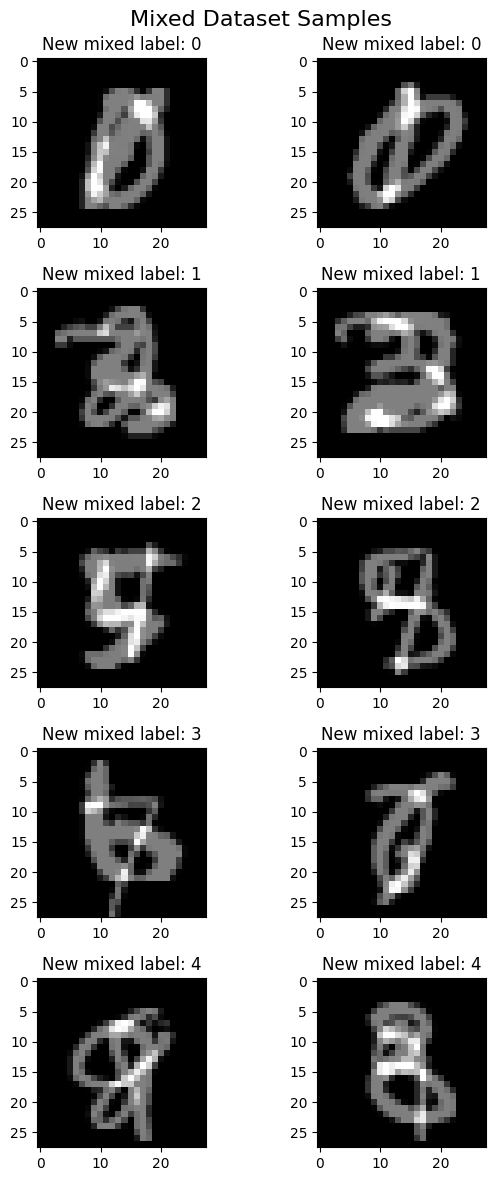

In [97]:
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

mixed_train_images = []
mixed_train_labels = []
mixed_test_images = []
mixed_test_labels = []

target_labels = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]

for mixed_label, (label_1, label_2) in enumerate(target_labels):

    train_images_1 = train_images[train_labels == label_1]
    train_images_2 = train_images[train_labels == label_2]
    test_images_1 = test_images[test_labels == label_1]
    test_images_2 = test_images[test_labels == label_2]

    np.random.shuffle(train_images_1)
    np.random.shuffle(train_images_2)
    np.random.shuffle(test_images_1)
    np.random.shuffle(test_images_2)

    N_train = min(len(train_images_1), len(train_images_2))
    N_test = min(len(test_images_1), len(test_images_2))

    for i in range(N_train):
        mixed_image = (train_images_1[i] + train_images_2[i]) / 2.0
        mixed_train_images.append(mixed_image)
        mixed_train_labels.append(mixed_label)

    for i in range(N_test):
        mixed_image = (test_images_1[i] + test_images_2[i]) / 2.0
        mixed_test_images.append(mixed_image)
        mixed_test_labels.append(mixed_label)

mixed_train_images = np.array(mixed_train_images, dtype="float32")
mixed_train_labels = np.array(mixed_train_labels, dtype="int8")
mixed_test_images = np.array(mixed_test_images, dtype="float32")
mixed_test_labels = np.array(mixed_test_labels, dtype="int8")

train_idx = np.random.permutation(len(mixed_train_images))
test_idx = np.random.permutation(len(mixed_test_images))

# final mixed datasets for use in training and testing
mixed_train_images = mixed_train_images[train_idx]
mixed_train_labels = mixed_train_labels[train_idx]
mixed_test_images = mixed_test_images[test_idx]
mixed_test_labels = mixed_test_labels[test_idx]

# ----- PLOTTING RANDOM SAMPLES ----- #
fig, axes = plt.subplots(5, 2, figsize=(6, 12))
fig.suptitle('Mixed Dataset Samples', fontsize=16)

for mixed_label in range(len(target_labels)):
    mixed_image = np.where(mixed_train_labels == mixed_label)[0][:2]

    for col_idx, image_idx in enumerate(mixed_image):
        ax = axes[mixed_label, col_idx]
        img = mixed_train_images[image_idx].reshape((28, 28))
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f'New mixed label: {mixed_label}')

fig.tight_layout()
plt.show()

---

## Problem 3



Design a neural network model to classify the 5 classes in the new dataset, and optimize it by tuning its hyper-parameters and trying our learned regualization techniques (such as L1 regularization, L2 regularization, dropout). 

    Your task: For your final (namely, optimized) neural network model, submit its code, and show the model's performance (including loss value and accuracy) for training, validation and testing. (For training performance and validation performance, illustrate them using figures, where the x-axis is the number of training epochs, and the y-axis is the loss or accuracy. For testing performance, just show the values of loss and accuracy.) Also, answer the questions: in this process of optimizing your model, did you observe underfitting? Did you observe overfitting? Did you try the reguliazation techniques? Did they help? 

---

My initial models were overfitting to the data, so I introduced dropout and l2 regularization, which improved the results.

1. The final model I ended up with has a 128W dense ReLU layer with an l2 regularizer (0.0001) followed by a 0.4 dropout, then the output softmax layer.
2. I settled around 15 epochs where I saw good training/validation accuracy and loss. 
3. Evalution of the mixed test images saw an accuracy of ~98% and a loss of ~8%, pretty good.
4. This model was fit with a validation split of 20% and a batch size of 128.

Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9021 - loss: 0.3412 - val_accuracy: 0.9531 - val_loss: 0.1664
Epoch 2/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9530 - loss: 0.1731 - val_accuracy: 0.9608 - val_loss: 0.1412
Epoch 3/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9599 - loss: 0.1483 - val_accuracy: 0.9642 - val_loss: 0.1290
Epoch 4/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9663 - loss: 0.1318 - val_accuracy: 0.9699 - val_loss: 0.1131
Epoch 5/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9692 - loss: 0.1187 - val_accuracy: 0.9728 - val_loss: 0.1064
Epoch 6/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9725 - loss: 0.1092 - val_accuracy: 0.9737 - val_loss: 0.1052
Epoch 7/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9746 - loss: 0.1001 - val_accuracy: 0.9754 - val_loss: 0.0989
Epoch 8/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9769 - loss: 0.0978 - val_accuracy: 0.

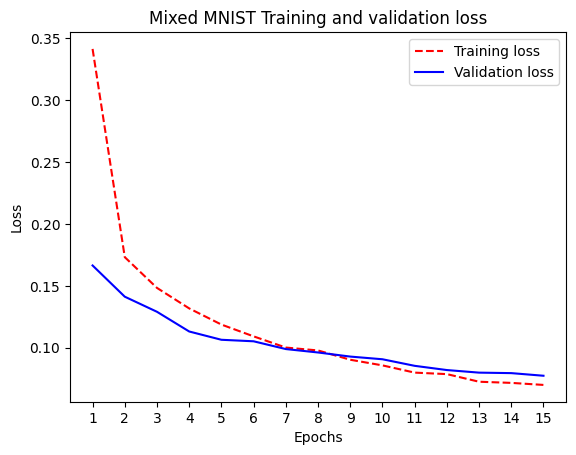

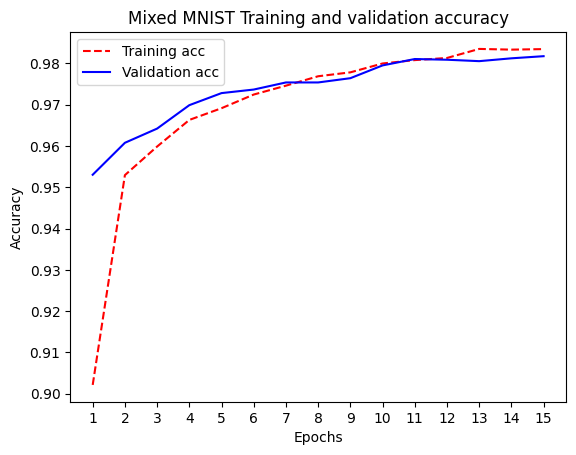

In [108]:
import keras
from keras import layers
from keras.regularizers import l1, l2

model = keras.Sequential(
    [
        # layers.Dense(16, activation="relu"),
        # layers.Dropout(0.5),

        # decent
        # layers.Dense(256, activation="relu", kernel_regularizer=l2(0.0001)),
        # layers.Dropout(0.4),

        # best training/validation accuracy & loss convergence
        layers.Dense(128, activation="relu", kernel_regularizer=l2(0.0001)),
        layers.Dropout(0.4),

        # final layer
        layers.Dense(5, activation="softmax")
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    mixed_train_images, 
    mixed_train_labels, 
    epochs=15, 
    batch_size=128,
    validation_split=0.2,
    shuffle=True,
)

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Mixed MNIST Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Mixed MNIST Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [109]:
results = model.evaluate(mixed_test_images, mixed_test_labels)

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - accuracy: 0.9774 - loss: 0.0873
